In [1]:
import pandas as pd
import xarray as xr

from utils.cfd_functions_post import read_foam_points, read_foam_faces_quad, read_foam_label_list, read_foam_internal_scalar, list_time_dirs, get_patch_faces_and_owner_cells, get_cell_centers, get_run_up_sim

In [2]:
read_foam_points('/nfs/home/geocean/alonsoap/projects/HyCFD/outputs/openfoam_cases/0000/constant/polyMesh/points')


array([[ 0.0000e+00, -1.5000e+01,  0.0000e+00],
       [ 2.0000e+00, -1.5000e+01,  0.0000e+00],
       [ 4.0000e+00, -1.5000e+01,  0.0000e+00],
       ...,
       [ 1.1990e+03,  2.7500e+01,  1.0000e-01],
       [ 1.1995e+03,  2.7500e+01,  1.0000e-01],
       [ 1.2000e+03,  2.7500e+01,  1.0000e-01]], shape=(231088, 3))

In [3]:
read_foam_faces_quad('/nfs/home/geocean/alonsoap/projects/HyCFD/outputs/openfoam_cases/0000/constant/polyMesh/faces')

array([[     1,    252,   4017,   3766],
       [   251,   4016,   4017,    252],
       [     2,    253,   4018,   3767],
       ...,
       [230552, 230553, 230731, 230730],
       [230730, 230731, 230909, 230908],
       [230908, 230909, 231087, 231086]], shape=(457975, 4))

In [4]:
read_foam_label_list('/nfs/home/geocean/alonsoap/projects/HyCFD/outputs/openfoam_cases/0000/constant/polyMesh/owner')

array([     0,      0,      1, ..., 113787, 113965, 114143],
      shape=(457975,))

In [5]:
read_foam_label_list('/nfs/home/geocean/alonsoap/projects/HyCFD/outputs/openfoam_cases/0000/constant/polyMesh/neighbour')

array([     1,    250,      2, ..., 114141, 114142, 114143],
      shape=(226889,))

In [6]:
alpha = read_foam_internal_scalar('/nfs/home/geocean/alonsoap/projects/HyCFD/outputs/openfoam_cases_backup/0000/0/alpha.water',51591)

In [7]:
list_time_dirs('/nfs/home/geocean/alonsoap/projects/HyCFD/outputs/openfoam_cases_backup/0000')

['0',
 '0.5',
 '1',
 '1.5',
 '2',
 '2.5',
 '3',
 '3.5',
 '4',
 '4.5',
 '5',
 '5.5',
 '6',
 '6.5',
 '7',
 '7.5',
 '8',
 '8.5',
 '9',
 '9.5',
 '10',
 '10.5',
 '11',
 '11.5',
 '12',
 '12.5',
 '13',
 '13.5',
 '14',
 '14.5',
 '15',
 '15.5',
 '16',
 '16.5',
 '17',
 '17.5',
 '18',
 '18.5',
 '19',
 '19.5',
 '20',
 '20.5',
 '21',
 '21.5',
 '22',
 '22.5',
 '23',
 '23.5',
 '24',
 '24.5',
 '25',
 '25.5',
 '26',
 '26.5',
 '27',
 '27.5',
 '28',
 '28.5',
 '29',
 '29.5',
 '30',
 '30.5',
 '31',
 '31.5',
 '32',
 '32.5',
 '33',
 '33.5',
 '34',
 '34.5',
 '35',
 '35.5',
 '36',
 '36.5',
 '37',
 '37.5',
 '38',
 '38.5',
 '39',
 '39.5',
 '40',
 '40.5',
 '41',
 '41.5',
 '42',
 '42.5',
 '43',
 '43.5',
 '44',
 '44.5',
 '45',
 '45.5',
 '46',
 '46.5',
 '47',
 '47.5',
 '48',
 '48.5',
 '49',
 '49.5',
 '50',
 '50.5',
 '51',
 '51.5',
 '52',
 '52.5',
 '53',
 '53.5',
 '54',
 '54.5',
 '55',
 '55.5',
 '56',
 '56.5',
 '57',
 '57.5',
 '58',
 '58.5',
 '59',
 '59.5',
 '60',
 '60.5',
 '61',
 '61.5',
 '62',
 '62.5',
 '63',
 '63.

In [8]:
a,b = get_patch_faces_and_owner_cells('/nfs/home/geocean/alonsoap/projects/HyCFD/outputs/openfoam_cases_backup/0000/constant/polyMesh','bottom')

In [ ]:
import numpy as np

def select_patch_cells(mesh_dir, patch_name, zC, yC, y_min_phys=None, tol_z=1e-6):

    # --- Middle z-plane (optional thin slice) ---
    z_mid = np.median(zC)
    keep2D = np.abs(zC - z_mid) < tol_z

    # --- Get patch faces and owner cells ---
    patch_face_ids, patch_owner_cells = get_patch_faces_and_owner_cells(mesh_dir, patch_name)

    # Unique patch cells
    patch_cells = np.unique(patch_owner_cells)  # already 0-based in Python

    # Keep only middle z-layer
    patch_cells = patch_cells[keep2D[patch_cells]]

    # Restrict by minimum y if specified
    if y_min_phys is not None and np.isfinite(y_min_phys):
        patch_cells = patch_cells[yC[patch_cells] >= y_min_phys]

    return patch_cells


In [10]:
t, ru, ru2 = get_run_up_sim(case_dir = '/nfs/home/geocean/alonsoap/projects/HyCFD/outputs/openfoam_cases_backup/0000')

In [13]:
ru2

np.float64(4.619601648)

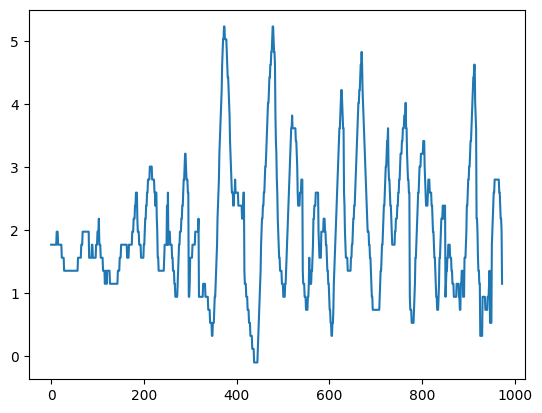

In [12]:
import matplotlib.pyplot as plt
plt.plot(ru)

In [11]:
xC, yC, zC, n_cells = get_cell_centers('/nfs/home/geocean/alonsoap/projects/HyCFD/outputs/openfoam_cases_backup/0000/constant/polyMesh')

ValueError: 'c' argument has 51591 elements, which is inconsistent with 'x' and 'y' with size 593.

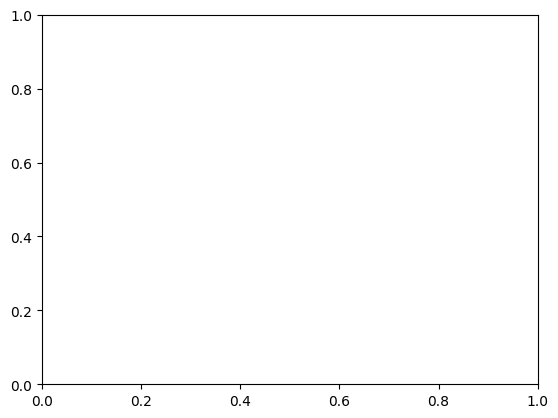

In [12]:
import matplotlib.pyplot as plt
plt.scatter(xC[[b]],yC[[b]],c=alpha)